<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 116 · Association Rule Mining</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Association Rule Mining</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Mining grocery market baskets for 'customers who bought X also bought Y' patterns with Apriori and FP-Growth, defining support, confidence, and lift, and showing why lift, not confidence, separates a real association from a popular-item mirage, all library-first with mlxtend, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Association Rule Mining: what goes with what
'Customers who bought this also bought...' Behind that everyday phrase is **association rule mining**: scanning millions of baskets to find items that co-occur far more than chance. This notebook mines grocery transactions with **Apriori** and **FP-Growth**, defines **support**, **confidence**, and **lift**, and shows why lift, not confidence, separates a real pattern from a popular-item mirage. Library-first with `mlxtend`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 160)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; FROM RECEIPTS TO A BASKET MATRIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">900 shopping trips</div>
<div style="color:#4a5578;margin-top:6px">Load long-format transactions and pivot to one-hot baskets.</div>
</div>

In [3]:
try: df = pd.read_excel('../../data/association-rule-mining--baskets.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'association-rule-mining--baskets.xlsx', sheet_name='Data')
print(df.head(6)); print('transactions:', df['transaction_id'].nunique(), '| items:', df['item'].nunique())
basket = df.assign(v=1).pivot_table(index='transaction_id', columns='item', values='v', fill_value=0).astype(bool)
print('basket matrix shape (trips x items):', basket.shape)

  transaction_id     item
0         T10000  lettuce
1         T10000     rice
2         T10001     beer
3         T10001  diapers
4         T10001     rice
5         T10002   cheese
transactions: 900 | items: 25
basket matrix shape (trips x items): (900, 25)


**The data shape mining needs.** Transactions arrive in **long** format, one row per item per basket. Rule mining needs a **one-hot basket matrix**: one row per shopping trip, one True/False column per item. A single `pivot_table` reshapes 900 trips into a 900-by-25 grid of booleans. Every algorithm below reads this matrix.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; SUPPORT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How often does an item (or set) appear?</div>
<div style="color:#4a5578;margin-top:6px">Support is just the fraction of baskets containing it.</div>
</div>

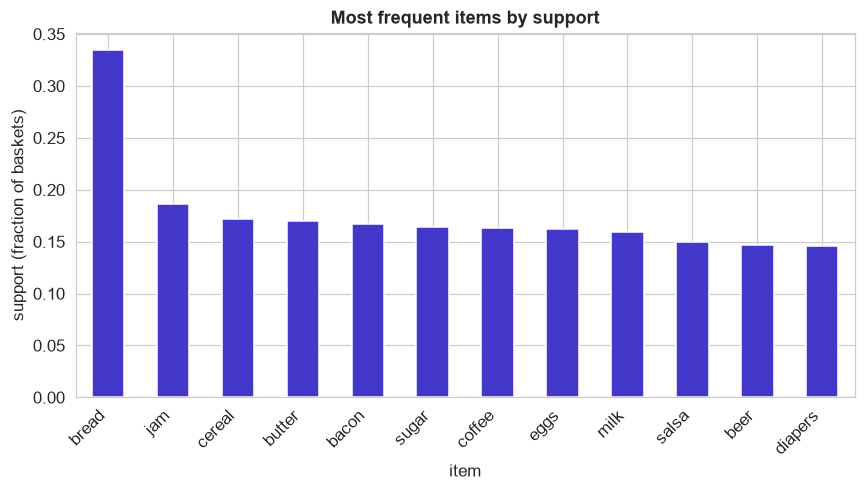

bread appears in 33% of baskets; diapers in 15%


In [4]:
support = basket.mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4.6))
support.head(12).plot.bar(color=EM, ax=ax)
ax.set(ylabel='support (fraction of baskets)', title='Most frequent items by support'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print('bread appears in %.0f%% of baskets; diapers in %.0f%%' % (support['bread']*100, support['diapers']*100))

**Support = popularity.** The **support** of an itemset is the fraction of all baskets that contain it. Bread shows up in a third of trips; nicher items far less. Support matters twice: rare itemsets are statistically flimsy (too few baskets to trust), and, as we will see, support is what makes mining every possible combination computationally feasible. We only chase patterns that clear a minimum support.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; APRIORI: FREQUENT ITEMSETS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Find every set that clears min support</div>
<div style="color:#4a5578;margin-top:6px">The Apriori trick: prune early, prune hard.</div>
</div>

In [5]:
freq = apriori(basket, min_support=0.03, use_colnames=True)
freq['n_items'] = freq['itemsets'].apply(len)
print('frequent itemsets found:', len(freq))
print(freq['n_items'].value_counts().sort_index().to_string())
print(freq[freq.n_items==2].sort_values('support', ascending=False).head(6).to_string(index=False))

frequent itemsets found: 61
n_items
1    25
2    27
3     8
4     1
 support                   itemsets  n_items
0.148889    frozenset({jam, bread})        2
0.142222 frozenset({butter, bread})        2
0.138889   frozenset({bacon, eggs})        2
0.136667   frozenset({butter, jam})        2
0.134444 frozenset({cereal, sugar})        2
0.133333   frozenset({bread, eggs})        2


**Why Apriori is fast.** There are astronomically many possible itemsets, checking them all is hopeless. Apriori uses one elegant rule (the **downward-closure principle**): if an itemset is infrequent, every larger set containing it must also be infrequent, so it can be pruned without checking. Starting from single items and growing only the survivors, Apriori explores a tiny fraction of the space. Here it finds the frequent pairs and triples above 3% support in a blink.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; RULES: CONFIDENCE AND LIFT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn itemsets into 'if A then B'</div>
<div style="color:#4a5578;margin-top:6px">Three numbers decide whether a rule is worth acting on.</div>
</div>

           A            B  support  confidence  lift
       salsa  chips, soda    0.092       0.615 5.704
 chips, soda        salsa    0.092       0.856 5.704
       pasta     parmesan    0.109       0.797 5.691
    parmesan        pasta    0.109       0.778 5.691
       salsa         soda    0.117       0.778 5.645
        soda        salsa    0.117       0.847 5.645
       chips        salsa    0.120       0.844 5.625
       salsa        chips    0.120       0.800 5.625
        soda chips, salsa    0.092       0.669 5.578
chips, salsa         soda    0.092       0.769 5.578


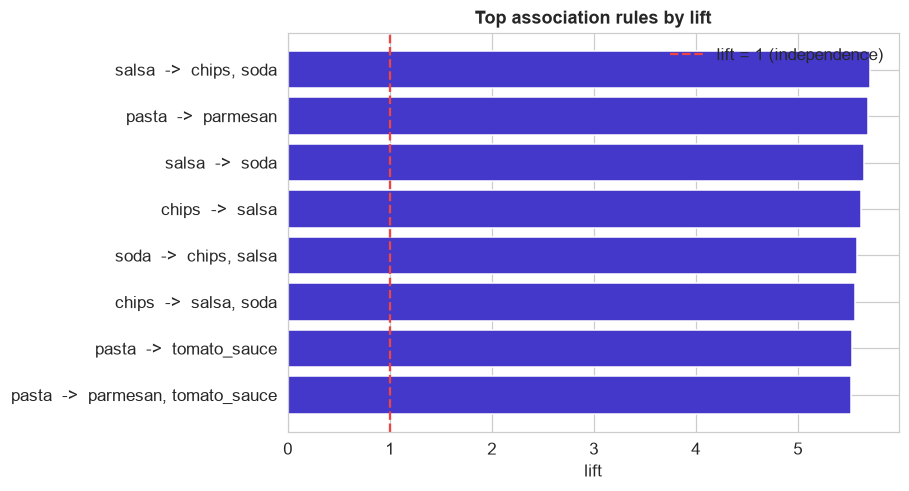

In [6]:
rules = association_rules(freq, metric='lift', min_threshold=1.0)
rules['A'] = rules['antecedents'].apply(lambda s: ', '.join(sorted(s)))
rules['B'] = rules['consequents'].apply(lambda s: ', '.join(sorted(s)))
top = rules.sort_values('lift', ascending=False)[['A','B','support','confidence','lift']].head(10)
print(top.round(3).to_string(index=False))
tl = rules.sort_values('lift', ascending=False).drop_duplicates('lift').head(8)[::-1]
labels = (tl['A'] + '  ->  ' + tl['B'])
fig, ax = plt.subplots(figsize=(8.4,4.6))
ax.barh(labels, tl['lift'], color=EM)
ax.axvline(1, color=RED, ls='--', label='lift = 1 (independence)')
ax.set(xlabel='lift', title='Top association rules by lift'); ax.legend()
plt.tight_layout(); plt.show()

**The three metrics.** A rule **A -> B** is scored by: **support** (how often A and B occur together, is it common enough to matter?), **confidence** (of baskets with A, what fraction also have B, how reliable is the rule?), and **lift** (how much more likely B is given A, versus B's baseline rate). **Lift > 1** means a genuine positive association; **lift = 1** means independence; **lift < 1** means the items repel. The top rules here, like {chips, soda} -> salsa, have lift above 5.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; WHY LIFT, NOT CONFIDENCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The popular-consequent trap</div>
<div style="color:#4a5578;margin-top:6px">Confidence ignores how common B already is; lift does not.</div>
</div>

a REAL association  diapers -> beer:
 support  confidence  lift
   0.108        0.74 5.049

baseline: bread is in 33% of ALL baskets
a COINCIDENCE  bananas -> bread (37%% confidence, but bread is just everywhere):
 support  confidence  lift
   0.047       0.368 1.102


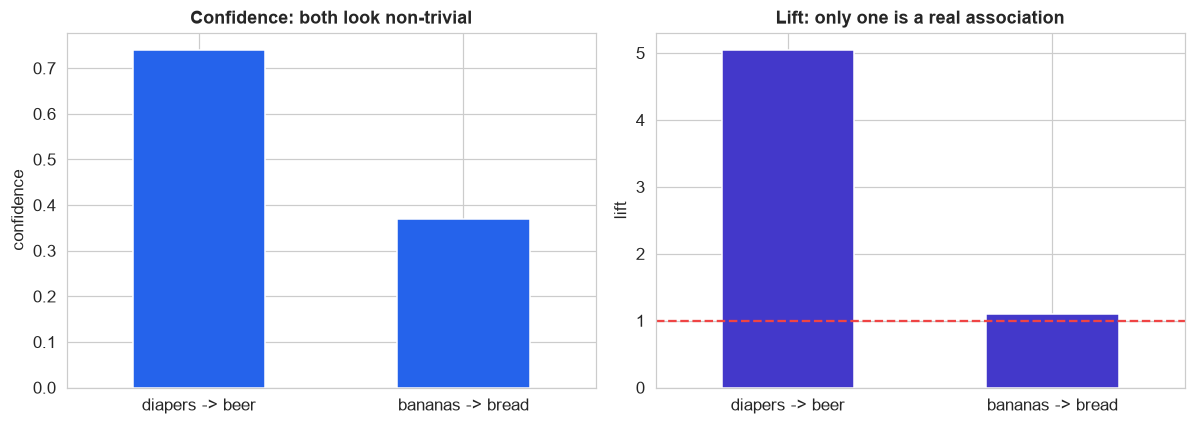

In [7]:
r = rules.copy()
diapers_beer = r[(r.A=='diapers') & (r.B=='beer')][['support','confidence','lift']]
print('a REAL association  diapers -> beer:'); print(diapers_beer.round(3).to_string(index=False))
print()
print('baseline: bread is in %.0f%% of ALL baskets' % (basket['bread'].mean()*100))
coincidence = r[(r.A=='bananas') & (r.B=='bread')][['support','confidence','lift']]
print('a COINCIDENCE  bananas -> bread (37%% confidence, but bread is just everywhere):')
print(coincidence.round(3).to_string(index=False))
cmp = pd.DataFrame({'confidence':[diapers_beer.confidence.iloc[0], coincidence.confidence.iloc[0]],
                    'lift':[diapers_beer.lift.iloc[0], coincidence.lift.iloc[0]]}, index=['diapers -> beer','bananas -> bread'])
fig, ax = plt.subplots(1, 2, figsize=(11,4))
cmp['confidence'].plot.bar(ax=ax[0], color=BLUE); ax[0].set(title='Confidence: both look non-trivial', ylabel='confidence'); ax[0].tick_params(axis='x', rotation=0)
cmp['lift'].plot.bar(ax=ax[1], color=EM); ax[1].axhline(1, color=RED, ls='--'); ax[1].set(title='Lift: only one is a real association', ylabel='lift'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**Confidence alone can mislead.** Take **bananas -> bread**: 37% of banana baskets also contain bread, which sounds like something, until you notice bread is in **33% of every basket anyway**. Buying bananas barely changes the odds, so its **lift is about 1.1**: essentially a coincidence driven by bread's popularity. Now contrast **diapers -> beer**: lift around 5 means a diaper-buyer is roughly five times likelier than average to also grab beer, a real, actionable pattern (the retail-legend rule, reproduced). Lift is confidence measured against the baseline, which is why you rank rules by **lift**, then filter by **support** to keep them common enough to matter.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 6 &#183; VISUALIZE + FP-GROWTH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">See the rules; then mine them faster</div>
<div style="color:#4a5578;margin-top:6px">A scatter of the rule set, and a quicker algorithm.</div>
</div>

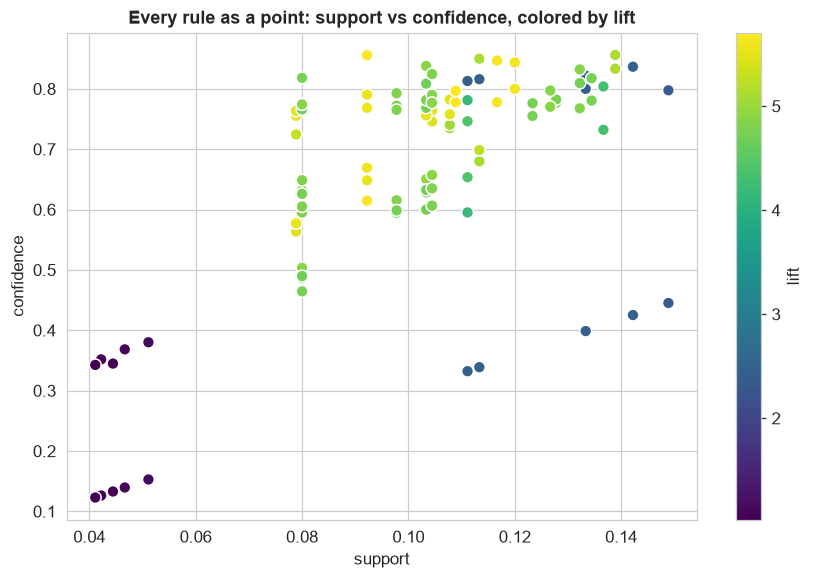

Apriori itemsets: 61 | FP-Growth itemsets: 61 -> identical results, FP-Growth is faster on large data


In [8]:
fig, ax = plt.subplots(figsize=(8,5.4))
sc = ax.scatter(rules['support'], rules['confidence'], c=rules['lift'], s=60, cmap='viridis', edgecolor='white')
plt.colorbar(sc, label='lift'); ax.set(xlabel='support', ylabel='confidence', title='Every rule as a point: support vs confidence, colored by lift')
plt.tight_layout(); plt.show()
freq_fp = fpgrowth(basket, min_support=0.03, use_colnames=True)
print('Apriori itemsets:', len(freq), '| FP-Growth itemsets:', len(freq_fp), '-> identical results, FP-Growth is faster on large data')

**Reading the rule set, and scaling it.** Each dot is one rule; the best live in the upper-right (reliable) and glow bright (high lift). This is how an analyst scans hundreds of rules at once and picks the few worth a promotion or a shelf change. **FP-Growth** is an alternative algorithm that finds the *same* frequent itemsets as Apriori but builds a compact tree instead of scanning repeatedly, so it is much faster on large catalogs, the go-to for real retail data.

## Association rule mining, in one view

- **Support** = fraction of baskets containing an itemset (popularity, and the key to fast pruning).
- **Confidence** = P(B given A); reliable-looking but inflated when B is popular.
- **Lift** = how many times more likely B is given A vs its baseline; **> 1** is a real association.
- **Apriori** prunes with the downward-closure principle; **FP-Growth** gets the same rules faster.
- Rank by **lift**, filter by **support**, then act, cross-sell, bundle, or re-shelve.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>